# Analyse et Prédiction des Retards de Vol

Ce notebook contient toutes les étapes d'analyse exploratoire, de préparation et de modélisation sur le jeu de données des retards d'avion.

## 1. Import des librairies

In [ ]:
%pip install pandas numpy matplotlib seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## 2. Chargement des données

In [ ]:
# Chargement du fichier CSV
try:
    df = pd.read_csv('./dataset/2016_01.csv')
except FileNotFoundError:
    df = None
    print("Fichier 'Dataset_RetardAvion.csv' non trouvé. Veuillez vérifier le nom ou le chemin.")

In [6]:
# Chargement d'un fichier CSV compressé .gz
gz_path = './dataset/2016_01.csv.gz'
try:
    df_gz = pd.read_csv(gz_path, compression='gzip')
    print(f"Fichier {gz_path} chargé avec succès.")
except FileNotFoundError:
    df_gz = None
    print(f"Fichier {gz_path} non trouvé. Veuillez vérifier le nom ou le chemin.")
except Exception as e:
    df_gz = None
    print(f"Erreur lors du chargement : {e}")

Fichier ./dataset/2016_01.csv.gz chargé avec succès.


In [7]:
df = df_gz

## 3. Exploration des données

In [8]:
# Aperçu des premières lignes
df.head() if df is not None else 'Données non chargées'

,YEAR,QUARTER,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,FL_DATE,UNIQUE_CARRIER,AIRLINE_ID,CARRIER,TAIL_NUM,...,DISTANCE_GROUP,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,FIRST_DEP_TIME,TOTAL_ADD_GTIME,LONGEST_ADD_GTIME,Unnamed: 64
0,2016,1,1,6,3,2016-01-06,AA,19805,AA,N4YBAA,...,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016,1,1,7,4,2016-01-07,AA,19805,AA,N434AA,...,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2016,1,1,8,5,2016-01-08,AA,19805,AA,N541AA,...,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2016,1,1,9,6,2016-01-09,AA,19805,AA,N489AA,...,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2016,1,1,10,7,2016-01-10,AA,19805,AA,N439AA,...,4,0.0,0.0,47.0,0.0,66.0,NaN,NaN,NaN,NaN


In [7]:
# Dimensions du dataset
df.shape if df is not None else 'Données non chargées'

(445827, 65)

In [8]:
# Types de variables
df.dtypes if df is not None else 'Données non chargées'

YEAR                     int64
QUARTER                  int64
MONTH                    int64
DAY_OF_MONTH             int64
DAY_OF_WEEK              int64
                        ...   
LATE_AIRCRAFT_DELAY    float64
FIRST_DEP_TIME         float64
TOTAL_ADD_GTIME        float64
LONGEST_ADD_GTIME      float64
Unnamed: 64            float64
Length: 65, dtype: object

In [9]:
# Statistiques descriptives
df.describe(include='all') if df is not None else 'Données non chargées'

,YEAR,QUARTER,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,FL_DATE,UNIQUE_CARRIER,AIRLINE_ID,CARRIER,TAIL_NUM,...,DISTANCE_GROUP,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,FIRST_DEP_TIME,TOTAL_ADD_GTIME,LONGEST_ADD_GTIME,Unnamed: 64
count,445827.0,445827.0,445827.0,445827.000000,445827.000000,445827,445827,445827.000000,445827,441583,...,445827.000000,70882.000000,70882.000000,70882.000000,70882.000000,70882.000000,2552.000000,2552.000000,2552.000000,0.0
unique,NaN,NaN,NaN,NaN,NaN,31,12,NaN,12,4238,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,2016-01-03,WN,NaN,WN,N489HA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,15878,104154,NaN,104154,358,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2016.0,1.0,1.0,15.893510,4.113815,NaN,NaN,19903.085069,NaN,NaN,...,3.848746,20.921912,2.836573,12.680455,0.080415,21.635450,1236.022335,32.054075,31.776254,NaN
std,0.0,0.0,0.0,8.936692,2.005007,NaN,NaN,382.853084,NaN,NaN,...,2.396397,57.041917,23.306995,24.859425,2.070844,41.991917,513.040425,25.993098,25.698255,NaN
min,2016.0,1.0,1.0,1.000000,1.000000,NaN,NaN,19393.000000,NaN,NaN,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,1.000000,1.000000,NaN
25%,2016.0,1.0,1.0,8.000000,2.000000,NaN,NaN,19790.000000,NaN,NaN,...,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,805.000000,15.000000,15.000000,NaN
50%,2016.0,1.0,1.0,16.000000,4.000000,NaN,NaN,19805.000000,NaN,NaN,...,3.000000,2.000000,0.000000,2.000000,0.000000,0.000000,1149.000000,25.000000,25.000000,NaN
75%,2016.0,1.0,1.0,24.000000,6.000000,NaN,NaN,20304.000000,NaN,NaN,...,5.000000,20.000000,0.000000,18.000000,0.000000,26.000000,1657.000000,39.000000,39.000000,NaN


In [10]:
# Aperçu des colonnes
df.columns if df is not None else 'Données non chargées'

Index(['YEAR', 'QUARTER', 'MONTH', 'DAY_OF_MONTH', 'DAY_OF_WEEK', 'FL_DATE',
       'UNIQUE_CARRIER', 'AIRLINE_ID', 'CARRIER', 'TAIL_NUM', 'FL_NUM',
       'ORIGIN_AIRPORT_ID', 'ORIGIN_AIRPORT_SEQ_ID', 'ORIGIN_CITY_MARKET_ID',
       'ORIGIN', 'ORIGIN_CITY_NAME', 'ORIGIN_STATE_ABR', 'ORIGIN_STATE_FIPS',
       'ORIGIN_STATE_NM', 'ORIGIN_WAC', 'DEST_AIRPORT_ID',
       'DEST_AIRPORT_SEQ_ID', 'DEST_CITY_MARKET_ID', 'DEST', 'DEST_CITY_NAME',
       'DEST_STATE_ABR', 'DEST_STATE_FIPS', 'DEST_STATE_NM', 'DEST_WAC',
       'CRS_DEP_TIME', 'DEP_TIME', 'DEP_DELAY', 'DEP_DELAY_NEW', 'DEP_DEL15',
       'DEP_DELAY_GROUP', 'DEP_TIME_BLK', 'TAXI_OUT', 'WHEELS_OFF',
       'WHEELS_ON', 'TAXI_IN', 'CRS_ARR_TIME', 'ARR_TIME', 'ARR_DELAY',
       'ARR_DELAY_NEW', 'ARR_DEL15', 'ARR_DELAY_GROUP', 'ARR_TIME_BLK',
       'CANCELLED', 'CANCELLATION_CODE', 'DIVERTED', 'CRS_ELAPSED_TIME',
       'ACTUAL_ELAPSED_TIME', 'AIR_TIME', 'FLIGHTS', 'DISTANCE',
       'DISTANCE_GROUP', 'CARRIER_DELAY', 'WEATHER_DELAY

In [11]:
# Vérification des valeurs manquantes
df.isnull().sum() if df is not None else 'Données non chargées'

YEAR                        0
QUARTER                     0
MONTH                       0
DAY_OF_MONTH                0
DAY_OF_WEEK                 0
                        ...  
LATE_AIRCRAFT_DELAY    374945
FIRST_DEP_TIME         443275
TOTAL_ADD_GTIME        443275
LONGEST_ADD_GTIME      443275
Unnamed: 64            445827
Length: 65, dtype: int64

## 4. Visualisations

<Axes: >

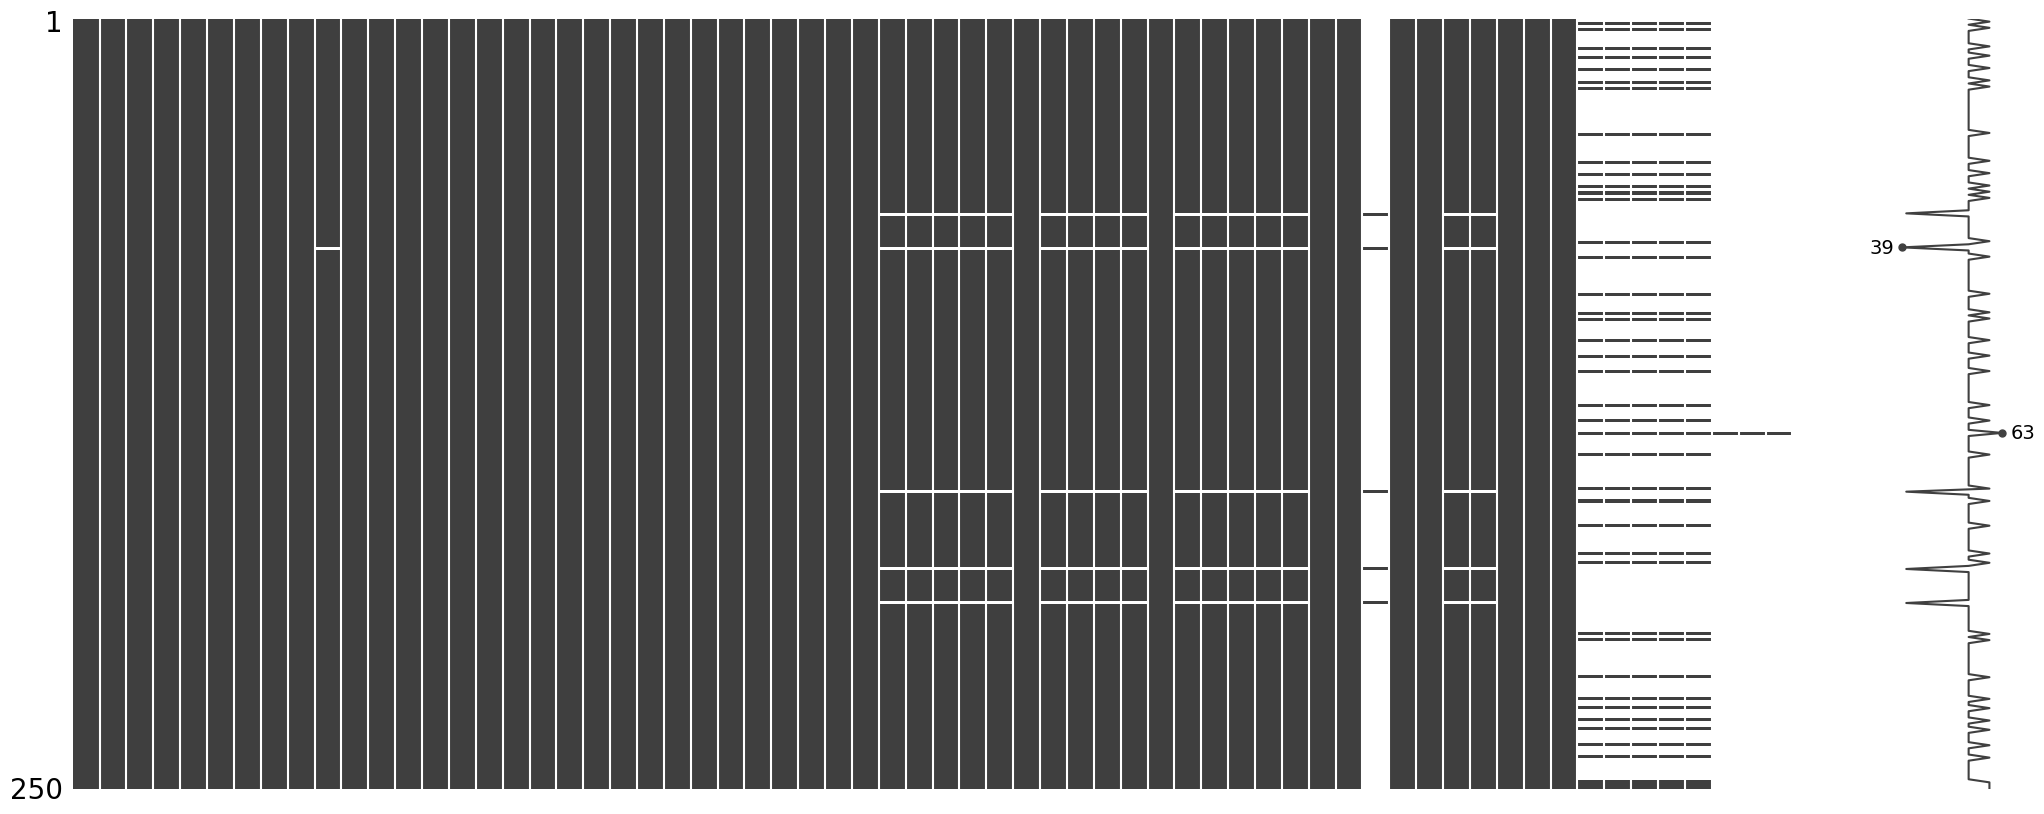

In [10]:
# %pip install missingno
import missingno as msno
%matplotlib inline
msno.matrix(df.sample(250))

## 5. Modélisation

In [15]:
# À compléter après exploration